<a href="https://colab.research.google.com/github/JosephWGLee/BML_GETS/blob/main/PFP_Raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 121 (delta 19), reused 111 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 62.31 KiB | 4.15 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/dlfb-clone


In [ ]:
%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,proteins,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.10.7 x86_64-unknown-linux-gnu
Resolved 144 packages in 7.28s
Using Python 3.12.12 environment at: /usr
Resolved 144 packages in 3.16s
Prepared 97 packages in 36.13s
Uninstalled 81 packages in 10.67s
Installed 98 packages in 1.31s
 - absl-py==1.4.0
 + absl-py==2.4.0
 + adjusttext==1.3.0
 - aiohttp==3.13.0
 + aiohttp==3.13.3
 - array-record==0.8.1
 + array-record==0.8.3
 + biopython==1.85
 - cachetools==5.5.2
 + cachetools==7.0.1
 - certifi==2025.10.5
 + certifi==2022.12.7
 - charset-normalizer==3.4.3
 + charset-normalizer==2.1.1
 - click==8.3.0
 + click==8.1.8
 - cryptography==43.0.3
 + cryptography==46.0.5
 - datasets==4.0.0
 + datasets==2.19.1
 + dlfb==0.1.1 (from file:///content/dlfb-clone)
 - einops==0.8.1
 + einops==0.8.2
 - flatbuffers==25.9.23
 + flatbuffers==25.12.19
 - flax==0.10.6
 + flax==0.10.4
 - fonttools==4.60.1
 + fonttools==4.61.1
 - fsspec==2025.3.0
 + fsspec==2024.3.1
 - gast==0.6.0
 + gast==0.7.0
 - google-api-core==2.25.2
 + google-api-core==2.30.0


In [ ]:
# NOTE: exclude models with '--no-models' flag
!dlfb-provision --chapter proteins

Files Downloaded: 100% 22/22 [00:09<00:00,  2.41file/s]


In [ ]:
# Toggle JAX_DISABLE_JIT to True for easier debugging
%env JAX_DISABLE_JIT=True

try:
  import dlfb
except ImportError as exc:
  # NOTE: Packages installed in editable mode are not immediately
  #       recognized by Colab (https://stackoverflow.com/a/63312333).
  import site
  site.main()
  import dlfb

from dlfb.utils.display import display

env: JAX_DISABLE_JIT=True


In [ ]:
#Importing pretrained ESMModel

from transformers import AutoTokenizer, EsmModel

model_checkpoint = "facebook/esm2_t33_650M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Loading CAFA 3 dataset

In [ ]:
from dlfb.utils.context import assets

labels = pd.read_csv(
    assets("proteins/datasets/train_terms.tsv.zip"), sep="\t", compression="infer"
)
print(labels)

            EntryID        term aspect
0        A0A009IHW8  GO:0008152    BPO
1        A0A009IHW8  GO:0034655    BPO
2        A0A009IHW8  GO:0072523    BPO
3        A0A009IHW8  GO:0044270    BPO
4        A0A009IHW8  GO:0006753    BPO
...             ...         ...    ...
5363858      X5L565  GO:0050649    MFO
5363859      X5L565  GO:0016491    MFO
5363860      X5M5N0  GO:0005515    MFO
5363861      X5M5N0  GO:0005488    MFO
5363862      X5M5N0  GO:0003674    MFO

[5363863 rows x 3 columns]


In [ ]:
import os
import obonet

def get_go_term_descriptions(store_path: str) -> pd.DataFrame:
  """Return GO term to description mapping, downloading if needed."""
  if not os.path.exists(store_path):
    url = "https://current.geneontology.org/ontology/go-basic.obo"
    graph = obonet.read_obo(url)

    # Extract GO term IDs and names from the graph nodes.
    id_to_name = {id: data.get("name") for id, data in graph.nodes(data=True)}
    go_term_descriptions = pd.DataFrame(
      zip(id_to_name.keys(), id_to_name.values()),
      columns=["term", "description"],
    )
    go_term_descriptions.to_csv(store_path, index=False)

  else:
    go_term_descriptions = pd.read_csv(store_path)
  return go_term_descriptions

In [ ]:
go_term_descriptions = get_go_term_descriptions(
  store_path=assets("proteins/datasets/go_term_descriptions.csv")
)
print(go_term_descriptions)

             term                                        description
0      GO:0000001                          mitochondrion inheritance
1      GO:0000002                   mitochondrial genome maintenance
2      GO:0000006  high-affinity zinc transmembrane transporter a...
3      GO:0000007  low-affinity zinc ion transmembrane transporte...
4      GO:0000009             alpha-1,6-mannosyltransferase activity
...           ...                                                ...
40209  GO:2001313  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40210  GO:2001314  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40211  GO:2001315  UDP-4-deoxy-4-formamido-beta-L-arabinopyranose...
40212  GO:2001316                       kojic acid metabolic process
40213  GO:2001317                    kojic acid biosynthetic process

[40214 rows x 2 columns]


In [ ]:
labels = labels.merge(go_term_descriptions, on="term")

In [ ]:
#Exclusive focus on molecular function

labels = labels[labels["aspect"] == "MFO"]
print(labels["description"].value_counts())

description
molecular_function                                78637
binding                                           57380
protein binding                                   47987
catalytic activity                                25324
heterocyclic compound binding                     12694
                                                  ...  
lovastatin nonaketide synthase activity               1
histone H3K37 methyltransferase activity              1
mitochondrion-plasma membrane adaptor activity        1
phenylacetate 2-hydroxylase activity                  1
NAD-dependent protein biotinidase activity            1
Name: count, Length: 6973, dtype: int64


In [ ]:
#Load FASTA protein sequences using SeqIO

from Bio import SeqIO
sequence_file = assets("proteins/datasets/train_sequences.fasta")
fasta_sequences = SeqIO.parse(open(sequence_file), "fasta")

data = []
for fasta in fasta_sequences:
  data.append(
      {
          "EntryID": fasta.id,
          "Sequence": str(fasta.seq),
          "Length": len(fasta.seq),
      }
  )
sequence_df = pd.DataFrame(data)
print(sequence_df)

           EntryID                                           Sequence  Length
0           P20536  MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...     218
1           O73864  MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...     354
2           O95231  MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...     258
3       A0A0B4J1F4  MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...     415
4           P54366  MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...     415
...            ...                                                ...     ...
142241  A0A286YAI0  METEVDDFPGKASIFSQVNPLYSNNMKLCEAERYDFQHSEPKTMKS...     450
142242  A0A1D5NUC4  MSAAASAEMIETPPVLNFEEIDYKEIEVEEVVGRGAFGVVCKAKWR...     643
142243      Q5RGB0  MADKGPILTSVIIFYLSIGAAIFQILEEPNLNSAVDDYKNKTNNLL...     448
142244  A0A2R8QMZ5  MGRKKIQITRIMDERNRQVTFTKRKFGLMKKAYELSVLCDCEIALI...     459
142245  A0A8I6GHU0  HCISSLKLTAFFKRSFLLSPEKHLVLLRDGRTLIGFLRSIDQFANL...     138

[142246 rows x 3 columns]


In [ ]:
#Isolate human proteins

taxonomy_file = assets("proteins/datasets/train_taxonomy.tsv.zip")
taxonomy = pd.read_csv(taxonomy_file, sep="\t", compression="infer")
sequence_df = sequence_df.merge(taxonomy, on="EntryID")
sequence_df = sequence_df[sequence_df["taxonomyID"] == 9606]
sequence_df = sequence_df.merge(labels, on="EntryID")

In [ ]:
print(
    f"Dataset contains {sequence_df["EntryID"].nunique()} human proteins with {sequence_df["term"].nunique()} molecular functions"
)

Dataset contains 16336 human proteins with 4101 molecular functions


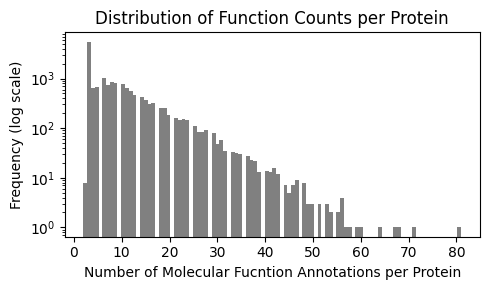

In [ ]:
#Distribution of number of functions per protein

sequence_df.groupby("EntryID")["term"].nunique().plot.hist(
    bins=100, figsize=(5,3), color="grey", log=True
)
plt.xlabel("Number of Molecular Fucntion Annotations per Protein")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Function Counts per Protein")
plt.tight_layout()

In [ ]:
#PREPROCESSING: remove overly generic terms

uninteresting_functions = [
    "GO:0003674", #mol function
    "GO:0005488", #binding
    "GO:0005515", #pro binding
]

sequence_df = sequence_df[~sequence_df["term"].isin(uninteresting_functions)]
sequence_df.shape

(106501, 7)

In [ ]:
#PREPROCESSING: remove rare terms >=50

common_functions = (
    sequence_df["term"]
    .value_counts()[sequence_df["term"].value_counts() >= 50]
    .index
)

sequence_df = sequence_df[sequence_df["term"].isin(common_functions)]
sequence_df["term"].value_counts()

,count
term,
GO:0003824,3875
GO:1901363,2943
GO:0003676,2469
GO:0042802,1803
GO:0016740,1652
...,...
GO:0005230,52
GO:0031490,51
GO:0005516,51


In [ ]:
#PREPROCESSING: mean embedding remove proteins with >500 Amino acids

sequence_df = sequence_df[sequence_df["Length"] <=500]

#Needs to be first 9000

In [ ]:
#Splitting datasets, 60% to training, remaining 40% to validation and test

from sklearn.model_selection import train_test_split

train_sequence_ids, valid_test_sequence_ids = train_test_split(
    list(set(sequence_df["EntryID"])), test_size=0.40, random_state=42
)

valid_sequence_ids, test_sequence_ids = train_test_split(
    valid_test_sequence_ids, test_size=0.50, random_state=42
)

In [ ]:
sequence_splits = {
    "train": sequence_df[sequence_df["EntryID"].isin(train_sequence_ids)],
    "valid": sequence_df[sequence_df["EntryID"].isin(valid_sequence_ids)],
    "test": sequence_df[sequence_df["EntryID"].isin(test_sequence_ids)],
}

for split, df in sequence_splits.items():
  print(f"{split} has {len(df)} entries.")

train has 25754 entries.
valid has 8603 entries.
test has 8370 entries.


In [ ]:
#Extract mean embeddings using a smaller ESM2 model. 320 dimensional representations

model_checkpoint = "facebook/esm2_t6_8M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from dlfb.proteins.dataset import (
  load_sequence_embeddings,
  store_sequence_embeddings,
)

In [ ]:
model_checkpoint = "facebook/esm2_t30_150M_UR50D"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = EsmModel.from_pretrained(model_checkpoint)

for split, df in sequence_splits.items():
  store_sequence_embeddings(
      sequence_df = df,
      store_prefix = assets(f"proteins/datasets/protein_dataset_{split}"),
      tokenizer = tokenizer,
      model = model,
  )

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t30_150M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_df = load_sequence_embeddings(
    assets("proteins/datasets/protein_dataset_train"),
    model_checkpoint=model_checkpoint,
)

print(train_df)

         EntryID                                           Sequence  Length  \
0     A0A0C4DG62  MAHVGSRKRSRSRSRSRGRGSEKRKKKSRKDTSRNCSASTSQERSK...     218   
1     A0A1B0GTB2   MVITSENDEDRGGQEKESKEESVLAMLGIIGTILNLIVIIFVYIYTTL      48   
2         A0AVI4  MDSPEVTFTLAYLVFAVCFVFTPNEFHAAGLTVQNLLSGWLGSEDA...     362   
3         A0PJW6  MAAPWRRWPTGLLAVLRPLLTCRPLQGTTLQRDVLLFEHDRGRFFT...     202   
4         A1L167  MKELQDIARLSDRFISVELVDESLFDWNVKLHQVDKDSVLWQDMKE...     161   
...          ...                                                ...     ...   
3569      Q9Y6N5  MVPLVAVVSGPRAQLFACLLRLGTQQVGPLQLHTGASHAARNHYEV...     450   
3570      Q9Y6P5  MRLAAAANEAYTAPLAVSGLLGCKQCGGGRDQDEELGIRIPRPLGQ...     492   
3571      Q9Y6W5  MPLVTRNIEPRHLCRQTLPSVRSELECVTNITLANVIRQLGSLSKY...     498   
3572      Q9Y6W6  MPPSPLDDRVVVALSRPVRPQDLNLCLDSSYLGSANPGSNSHPPVI...     482   
3573      Q9Y6Y9  MLPFLFFSTLFSSIFTEAQKQYWVCNSSDASISYTYCDKMQYPISI...     160   

      GO:0000166  GO:0000287  GO:0000976  GO:000097

In [ ]:
#Build tensorflow compatible dataset

from dlfb.proteins.dataset import convert_to_tfds
display(["import tensorflow as tf", convert_to_tfds])
train_ds = convert_to_tfds(train_df, is_training = True)

batch_size = 32

batch = next(train_ds.batch(batch_size).as_numpy_iterator())
batch["embedding"].shape, batch["target"].shape

#640 dimensional embedding vector and a target of a 303 dimensional binary vector

import tensorflow as tf

def convert_to_tfds(
  df: pd.DataFrame,
  embeddings_prefix: str = "ME:",
  target_prefix: str = "GO:",
  is_training: bool = False,
  shuffle_buffer: int = 50,
) -> tf.data.Dataset:
  """Convert embedding DataFrame into a TensorFlow dataset."""
  dataset = tf.data.Dataset.from_tensor_slices(
    {
      "embedding": df.filter(regex=f"^{embeddings_prefix}").to_numpy(),
      "target": df.filter(regex=f"^{target_prefix}").to_numpy(),
    }
  )
  if is_training:
    dataset = dataset.shuffle(shuffle_buffer).repeat()
  return dataset

((32, 640), (32, 303))

In [ ]:
#Build the pipeline and split the dataset

import tensorflow as tf

def build_dataset(store_file_prefix: str, model_checkpoint: str) -> dict[str, tf.data.Dataset]:

  dataset_splits = {}

  for split in ["train", "valid", "test"]:
    dataset_splits[split] = convert_to_tfds(
        df=load_sequence_embeddings(store_file_prefix=f"{store_file_prefix}_{split}", model_checkpoint = model_checkpoint,),
        is_training=(split == "train")
    )
  return dataset_splits

In [ ]:
dataset_splits = build_dataset(
  assets("proteins/datasets/protein_dataset"), model_checkpoint=model_checkpoint
)

In [ ]:
#Train the model on top of mean embeddings

import flax.linen as nn
from flax.training.train_state import TrainState

class Model(nn.Module):
  """Simple MLP for protein function prediction"""

  num_targets: int
  dim: int = 256

  @nn.compact
  def __call__(self, x):
    """Apply MLP layers to input features"""
    x = nn.Sequential(
        [
            nn.Dense(self.dim*2),
            jax.nn.gelu,
            nn.Dense(self.dim),
            jax.nn.gelu,
            nn.Dense(self.num_targets),
        ]
      )(x)
    return x

In [ ]:
def create_train_state(self, rng: jax.Array, dummy_input, tx) -> TrainState:
  variables=self.init(rng, dummy_input)
  return TrainState.create(apply_fn=self.apply, params=variables["params"], tx=tx)

In [ ]:
targets = list(train_df.columns[train_df.columns.str.contains("GO:")])
mlp = Model(num_targets=len(targets))

In [ ]:
#Training loop, forward pass through model computing loss

import jax

@jax.jit #Jax just in time compilation (speeds it all up)
def train_step(state, batch):
  """Run a single training step and update model parametres"""

  def calculate_loss(params):
    """Compute sigmoid cross-entropy loss from logits""" #(unnormalised numerical scores/sigmoid curve loss)
    logits = state.apply_fn({"params":params}, x=batch["embedding"])
    loss = optax.sigmoid_binary_cross_entropy(logits, batch["target"]).mean()
    return loss

  grad_fn = jax.value_and_grad(calculate_loss, has_aux=False)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [ ]:
#Compute accuracy

import sklearn

def compute_metrics(
    targets: np.ndarray, probs: np.ndarray, thresh=0.5
) -> dict[str, float]:

  if np.sum(targets)==0:
    return {
        m: 0.0 for m in ["accuracy", "recall", "precision", "auprc", "auroc"]
    }

  return {
      "accuracy": metrics.accuracy_score(targets, probs >= thresh),
      "recall": metrics.recall_score(targets, probs >= thresh).item(),
      "precision": metrics.precision_score(targets, probs >= thresh, zero_division = 0.0,).item(),
      "auprc": metrics.average_precision_score(targets, probs).item(),
      "auroc": metrics.roc_auc_score(targets, probs).item(),
  }

In [ ]:
def eval_step(state, batch) -> dict[str,float]:
  """Run evaluation step. Return mean metrics over the targets"""
  logits=state.apply_fn({"params":state.params}, x=batch["embedding"])
  loss=optax.sigmoid_binary_cross_entropy(logits, batch["target"]).mean()
  target_metrics=calculate_per_target_metrics(logits, batch["target"])
  metrics={"loss":loss.item(), **pd.DataFrame(target_metrics).mean(axis=0).to_dict(),}
  return metrics

def calculate_per_target_metrics(logits, targets):
  """Compute metrics for each target in a multi-label batch"""
  probs=jax.nn.sigmoid(logits)
  target_metrics=[]
  for target, prob in zip(targets, probs):
    target_metrics.append(compute_metrics(target, prob))
  return target_metrics

In [ ]:
from dlfb.proteins.train import train

display([train])

def train(
  state: TrainState,
  dataset_splits: dict[str, tf.data.Dataset],
  batch_size: int,
  num_steps: int = 300,
  eval_every: int = 30,
):
  """Train model using batched TF datasets and track performance metrics."""
  # Create containers to handle calculated during training and evaluation.
  train_metrics, valid_metrics = [], []

  # Create batched dataset to pluck batches from for each step.
  train_batches = (
    dataset_splits["train"]
    .batch(batch_size, drop_remainder=True)
    .as_numpy_iterator()
  )

  steps = tqdm(range(num_steps))  # Steps with progress bar.
  for step in steps:
    steps.set_description(f"Step {step + 1}")

    # Get batch of training data, convert into a JAX array, and train.
    state, loss = train_step(state, next(train_batches))
    train_metrics.append({"step": step, "loss": loss.item()})

    if step % eval_every == 0:
      # For all the evaluation batches, calculate metrics.
      eval_metrics = []
      for eval_batch in (
        dataset_splits["valid"].batch(batch_size=batch_size).as_numpy_iterator()
      ):
        eval_metrics.append(eval_step(state, eval_batch))
      valid_metrics.append(
        {"step": step, **pd.DataFrame(eval_metrics).mean(axis=0).to_dict()}
      )

  return state, {"train": train_metrics, "valid": valid_metrics}

In [ ]:
#Identification of train and skipping if necessary

import optax

from dlfb.utils.restore import restorable

# Initiate training state with dummy data from a single batch.
rng = jax.random.PRNGKey(42)
rng, rng_init = jax.random.split(key=rng, num=2)

state, metrics = restorable(train)(
  state=mlp.create_train_state(
    rng=rng_init, dummy_input=batch["embedding"], tx=optax.adam(0.001)
  ),
  dataset_splits=dataset_splits,
  batch_size=32,
  num_steps=300,
  eval_every=30,
  store_path=assets("proteins/models/mlp"),
)

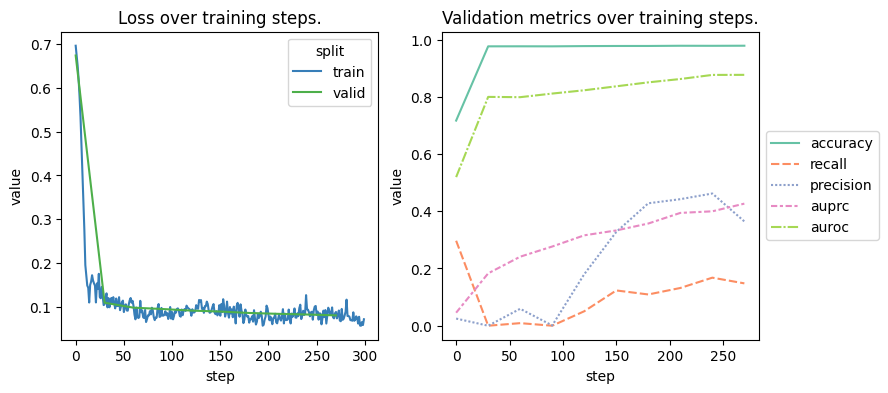

In [ ]:
#Evaluation of training dynamics and performance on validation set

import matplotlib.pyplot as plt
import seaborn as sns

from dlfb.utils.metric_plots import DEFAULT_SPLIT_COLORS

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4))

#Training loss curve
learning_data = pd.concat(
    pd.DataFrame(metrics[split]).melt("step").assign(split=split)
    for split in ["train", "valid"]
)

sns.lineplot(
    ax=ax[0],
    x="step",
    y="value",
    hue="split",
    data=learning_data[learning_data["variable"] == "loss"],
    palette = DEFAULT_SPLIT_COLORS,
)
ax[0].set_title("Loss over training steps.")

#Validation metrics curve
sns.lineplot(
    ax=ax[1],
    x="step",
    y="value",
    hue="variable",
    style="variable",
    data=learning_data[learning_data["variable"] != "loss"],
    palette="Set2",
)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax[1].set_title("Validation metrics over training steps.");

In [ ]:
valid_df = load_sequence_embeddings(
    store_file_prefix=f"{assets("proteins/datasets/protein_dataset")}_valid",
    model_checkpoint = model_checkpoint,
)

print(valid_df)

     EntryID                                           Sequence  Length  \
0     A1A4Y4  MEAMNVEKASADGNLPEVISNIKETLKIVSRTPVNITMAGDSGNGM...     181   
1     A5LHX3  MALQDVCKWQSPDTQGPSPHLPRAGGWAVPRGCDPQTFLQIHGPRL...     300   
2     A5PLL7  MAGAENWPGQQLELDEDEASCCRWGAQHAGARELAALYSPGKRLQE...     270   
3     A6NHX0  MELHILEHRLQVASVAKESIPLFTYGLIKLAFLSSKTRCKFFSLTE...     329   
4     A6NJ46  MESNLQGTFLLNNTPLAQFPEMKAPVCQYSVQNSFYKLSPPGLGPQ...     265   
...      ...                                                ...     ...   
1186  Q9Y6J6  MSTLSNFTQTLEDVFRRIFITYMDNWRQNTTAEQEALQAKVDAENF...     123   
1187  Q9Y6K0  MSGHRSTRKRCGDSHPESPVGFGHMSTTGCVLNKLFQLPTPPLSRH...     416   
1188  Q9Y6K9  MNRHLWKSQLCEMVQPSGGPAADQDVLGEESPLGKPAMLHLPSEQG...     419   
1189  Q9Y6V7  MAGFAELGLSSWLVEQCRQLGLKQPTPVQLGCIPAILEGRDCLGCA...     483   
1190  Q9Y6Z7  MNGFASLLRRNQFILLVLFLLQIQSLGLDIDSRPTAEVCATHTISP...     277   

      GO:0000166  GO:0000287  GO:0000976  GO:0000977  GO:0000978  GO:0000981  \
0              0   

In [ ]:
#Batch size of one prevent dropping remainder

valid_probs = []
for valid_batch in dataset_splits["valid"].batch(1).as_numpy_iterator():
  logits = state.apply_fn({"params":state.params}, x=valid_batch["embedding"])
  valid_probs.extend(jax.nn.sigmoid(logits))

valid_true_df = valid_df[["EntryID"] + targets].set_index("EntryID")
valid_prob_df = pd.DataFrame(
    np.stack(valid_probs), columns=targets, index=valid_true_df.index
)

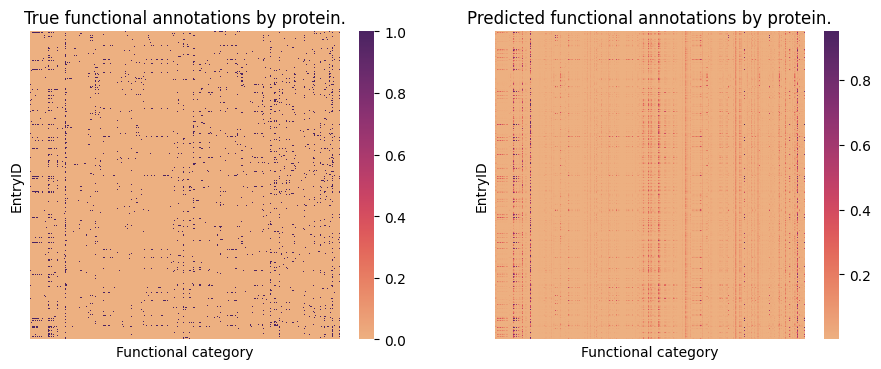

In [ ]:
#Heatmap of predicted protein function

#Left ground truth. Right is predicted probabilities

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(11,4))

sns.heatmap(
    ax=ax[0],
    data=valid_true_df,
    yticklabels=False,
    xticklabels=False,
    cmap="flare",
)
ax[0].set_title("True functional annotations by protein.")
ax[0].set_xlabel("Functional category")

sns.heatmap(
    ax=ax[1],
    data=valid_prob_df,
    yticklabels=False,
    xticklabels=False,
    cmap="flare"
)

ax[1].set_title("Predicted functional annotations by protein.")
ax[1].set_xlabel("Functional category");

In [ ]:
#Quantify

metrics_by_function ={}
for function in targets:
  metrics_by_function[function] = compute_metrics(
      valid_true_df[function].values, valid_prob_df[function].values
  )

overview_valid = (
    pd.DataFrame(metrics_by_function)
    .T.merge(go_term_descriptions, left_index=True, right_on="term")
    .set_index("term")
    .sort_values("auprc", ascending=False)
)

print(overview_valid)

            accuracy    recall  precision     auprc     auroc  \
term                                                            
GO:0004930  0.958858  0.000000   0.000000  0.948591  0.982272   
GO:0004888  0.945424  0.177215   1.000000  0.849885  0.968354   
GO:0003824  0.848027  0.731591   0.819149  0.849362  0.909372   
GO:1990837  0.954660  0.543689   0.888889  0.825313  0.970820   
GO:0043565  0.955500  0.649123   0.850575  0.821888  0.963243   
...              ...       ...        ...       ...       ...   
GO:0004714  0.999160  0.000000   0.000000  0.001094  0.232773   
GO:0042626  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0051015  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0003774  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:1902936  0.000000  0.000000   0.000000  0.000000  0.000000   

                                                  description  
term                                                           
GO:0004930                

In [ ]:
overview_valid = overview_valid.merge(
    pd.DataFrame(train_df[targets].sum(), columns=["train_n"]),
    left_index=True,
    right_index=True,
)
print(overview_valid)

            accuracy    recall  precision     auprc     auroc  \
GO:0004930  0.958858  0.000000   0.000000  0.948591  0.982272   
GO:0004888  0.945424  0.177215   1.000000  0.849885  0.968354   
GO:0003824  0.848027  0.731591   0.819149  0.849362  0.909372   
GO:1990837  0.954660  0.543689   0.888889  0.825313  0.970820   
GO:0043565  0.955500  0.649123   0.850575  0.821888  0.963243   
...              ...       ...        ...       ...       ...   
GO:0004714  0.999160  0.000000   0.000000  0.001094  0.232773   
GO:0042626  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0051015  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:0003774  0.000000  0.000000   0.000000  0.000000  0.000000   
GO:1902936  0.000000  0.000000   0.000000  0.000000  0.000000   

                                                  description  train_n  
GO:0004930                G protein-coupled receptor activity      138  
GO:0004888          transmembrane signaling receptor activity      228  


Text(0, 0.5, 'Validation auPRC')

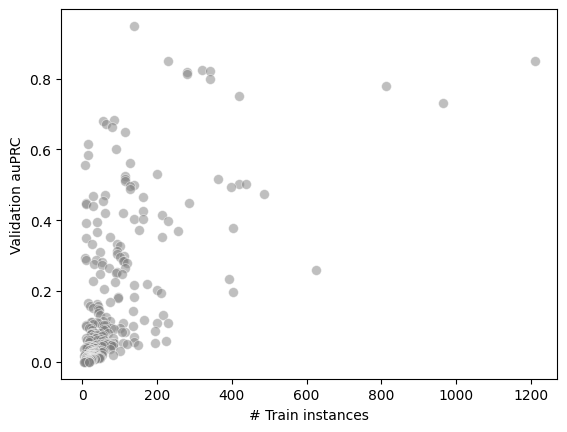

In [ ]:
#Scatterplot visualisation

fig = sns.scatterplot(
    x="train_n", y="auprc", data=overview_valid, alpha=0.5, s=50, color="grey"
)
fig.set_xlabel("# Train instances")
fig.set_ylabel("Validation auPRC")

In [ ]:
def make_coin_flip_predictions(
    valid_true_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:
  predictions = np.random.choice([0.0, 1.0], size=valid_true_df.shape)
  return pd.DataFrame(predictions, columns=targets, index=valid_true_df.index)

def make_proportional_predictions(
   valid_true_df: pd.DataFrame, train_df: pd.DataFrame, targets: list[str]
) -> pd.DataFrame:

  percent_1_train = dict(train_df[targets].mean())
  proportional_preds = []
  for target_column in targets:
    prob_1 = percent_1_train[target_column]
    prob_0 = 1 - prob_1
    proportional_preds.append(
        np.random.choice([0.0, 1.0], size=len(valid_true_df), p=[prob_0, prob_1])
    )
  return pd.DataFrame(
      np.stack(proportional_preds).T, columns=targets, index=valid_true_df.index
  )

In [ ]:
prediction_methods = {
    "coin_flip_baseline": make_coin_flip_predictions(valid_true_df, targets),
    "proportional_guess_baseline": make_proportional_predictions(
        valid_true_df, train_df, targets
    ),
    "model": valid_prob_df,
}

In [ ]:
metrics_by_method ={}
for method, preds_df in prediction_methods.items():
  metrics_by_method[method] = pd.DataFrame(
      [
          compute_metrics(valid_true_df.iloc[i], preds_df.iloc[i])
          for i in range (len(valid_true_df))
      ]
  ).mean()

print(pd.DataFrame(metrics_by_method))

           coin_flip_baseline  proportional_guess_baseline     model
accuracy             0.500090                     0.956458  0.978569
recall               0.499020                     0.092954  0.128532
precision            0.023612                     0.083551  0.424301
auprc                0.025218                     0.040425  0.412350
auroc                0.499528                     0.535267  0.882679


In [ ]:
auprc_by_function = {}

for method, preds_df in prediction_methods.items():
  metrics_by_function = {}

  for function in targets:
    metrics_by_function[function] = compute_metrics(
        valid_true_df[function], preds_df[function]
    )

  auprc_by_function[method] = (
      pd.DataFrame(metrics_by_function)
      .T.merge(go_term_descriptions, left_index=True, right_on="term")
      .set_index("term")
      .sort_values("auprc", ascending=False)
  )["auprc"].to_dict()

/tmp/ipython-input-646643500.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


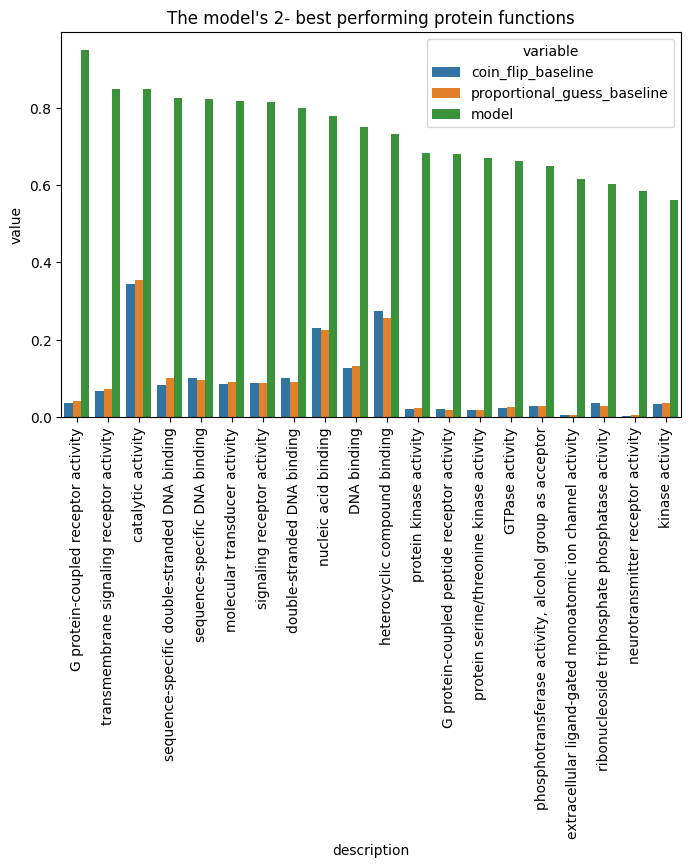

In [ ]:
#Visualise function level auprc scores as a bar plot to highlight functional categories

best_performing = (
    pd.DataFrame(auprc_by_function)
    .merge(go_term_descriptions, left_index=True, right_on="term")
    .set_index("term")
    .sort_values("model", ascending=False)
    .head(20)
    .melt("description")
)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    x="description",
    y="value",
    hue="variable",
    data=best_performing,
)
ax.set_title("The model's 2- best performing protein functions")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);